In [18]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

%config InlineBackend.figure_format='retina'
plt.rc('text', usetex=True)


### Tasks

**Remember this is a real research example, not an exam! You're welcome (and encouraged actually!) to use all the tutorials/answers/hack you find online!**


1) Read in `solutions/transient.npy`. This is a (100 x 3) numpy array, containing some time-series measurements from a transient phenomenon. The first column is time (arbitrary units), the second column is the flux (arbitrary units), and the third column are homoescedastic measurement uncertainties on the flux. Plot this data with the uncertainties.


In [19]:
data = np.load('../solutions/transient.npy')

In [20]:
t, f, ferr = data.T

Text(0, 0.5, 'flux')

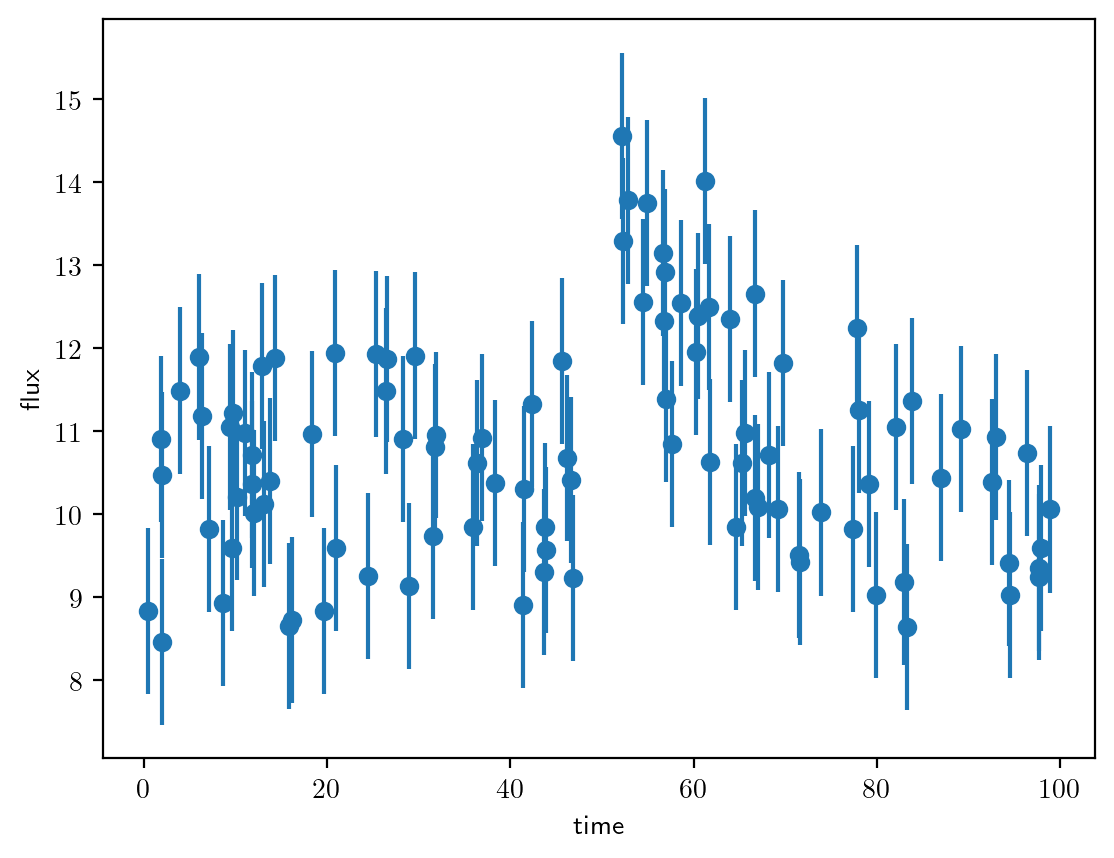

In [21]:
plt.errorbar(t, f, ferr, marker = 'o', ls = '')
plt.xlabel('time')
plt.ylabel('flux')

2) One possible model for this data is a sharp burst with an exponential tail rising above a nominal background level. This model can be described as:

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

where $b$ is the background amplitude, $A$ is the burst amplitude, $t_0$ is the burst epoch, and $\alpha$ encodes how rapidly the burst dies off.

Code this burst model, and code a likelihood function for this data with the burst model. *Hint: This is similar in spirit to the likelihood when fitting polynomials to data, except now $x$ is time, and the polynomial model is now the burst model.* 

In [22]:
def model(t,A,b,alpha,t0):
    y = np.ones_like(t)*b
    y[t>t0] += A*np.exp(-alpha*(t[t>t0]-t0))
    return y

def logl(theta,t,f,ferr):
    A,b,alpha,t0 = theta
    return -1./2.*np.sum(((f-model(t,A,b,alpha,t0))/ferr)**2)


3) Using one of the MCMC sampler that we looked at in class (`emcee`, `pymc`), perform a Bayesian analysis that recovers an MCMC chain of posterior probability samples for the joint parameter space of $\{b,A,t_0,\alpha\}$. You must decide on how many samples are appropriate for running your MCMC. For your priors, make them $b\in \mathrm{Uniform}[0,50]$, $A\in \mathrm{Uniform}[0,50]$, $t_0\in \mathrm{Uniform}[0,100]$, and $\ln\alpha\in \mathrm{Uniform}[-5,5]$ (careful: uniform in $\ln\alpha$, not $\alpha$).


$p(x)dx = p(y)dy \quad \rightarrow \quad p(log(\alpha))=p(\alpha)/\alpha$

In [23]:
def logpr(theta):
    A,b,alpha,t0 = theta
    lna = np.log(alpha)
    if 0. < b < 50. and 0. < A < 50. and 0. < t0 < 100. and -5. < lna < 5.:
        return 0.-lna
    return -np.inf

In [24]:
# emcee
def logpost(theta,t,f,ferr):
    lp = logpr(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + logl(theta,t,f,ferr)

In [25]:
ndim = 4
nwalkers = 10
burn = 1000
nsteps = 100000

guess = np.random.random((nwalkers, ndim))+[5.,10.,.1,50.]

In [26]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, logpost, args=[t, f, ferr])
_ = sampler.run_mcmc(guess, nsteps, progress = True)

  0%|          | 0/100000 [00:00<?, ?it/s]/var/folders/_h/ldjx52094bd50nf5x0f85ybr0000gn/T/ipykernel_13005/777641865.py:3: RuntimeWarning: invalid value encountered in log
  lna = np.log(alpha)
100%|██████████| 100000/100000 [00:25<00:00, 3968.83it/s]


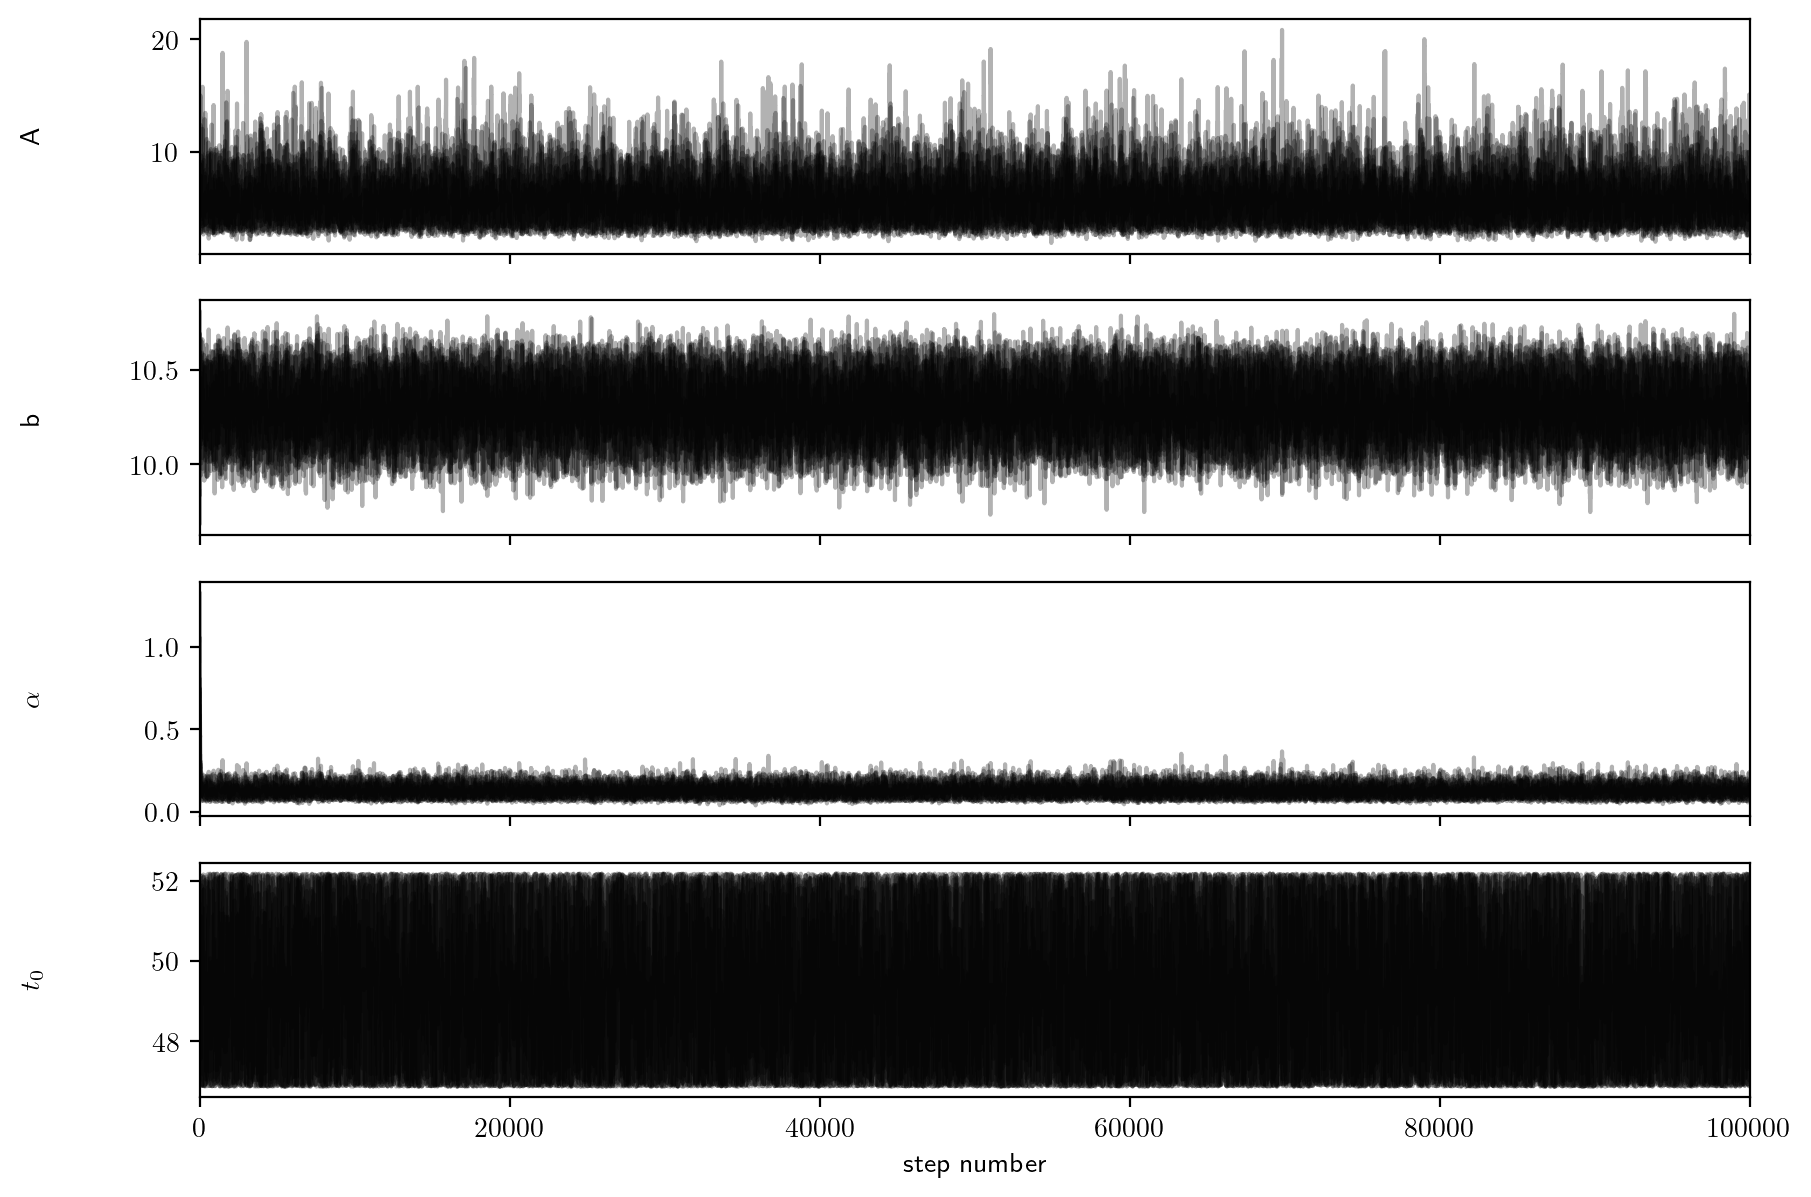

In [27]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ['A','b',r'$\alpha$',r'$t_0$']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");


4) Perform an appropriate check to burn-in your chain, and thin the chain by selecting only points every auto-correlation length. If you are left with a small number of samples after thinning then you may need to run your MCMC for longer in (3).


In [35]:
tau = sampler.get_autocorr_time()
print(tau)

[93.06950211 73.68346739 75.26679007 95.16180583]


In [36]:
flat_samples = sampler.get_chain(discard=burn, thin=int(2*max(tau)), flat=True) # thin by about half autocorrelation time
print(flat_samples.shape)

(5210, 4)


5) Make a corner plot of the $4$-D parameter space, with labels, $[68,95]\%$ credible levels and quantiles, and titles.

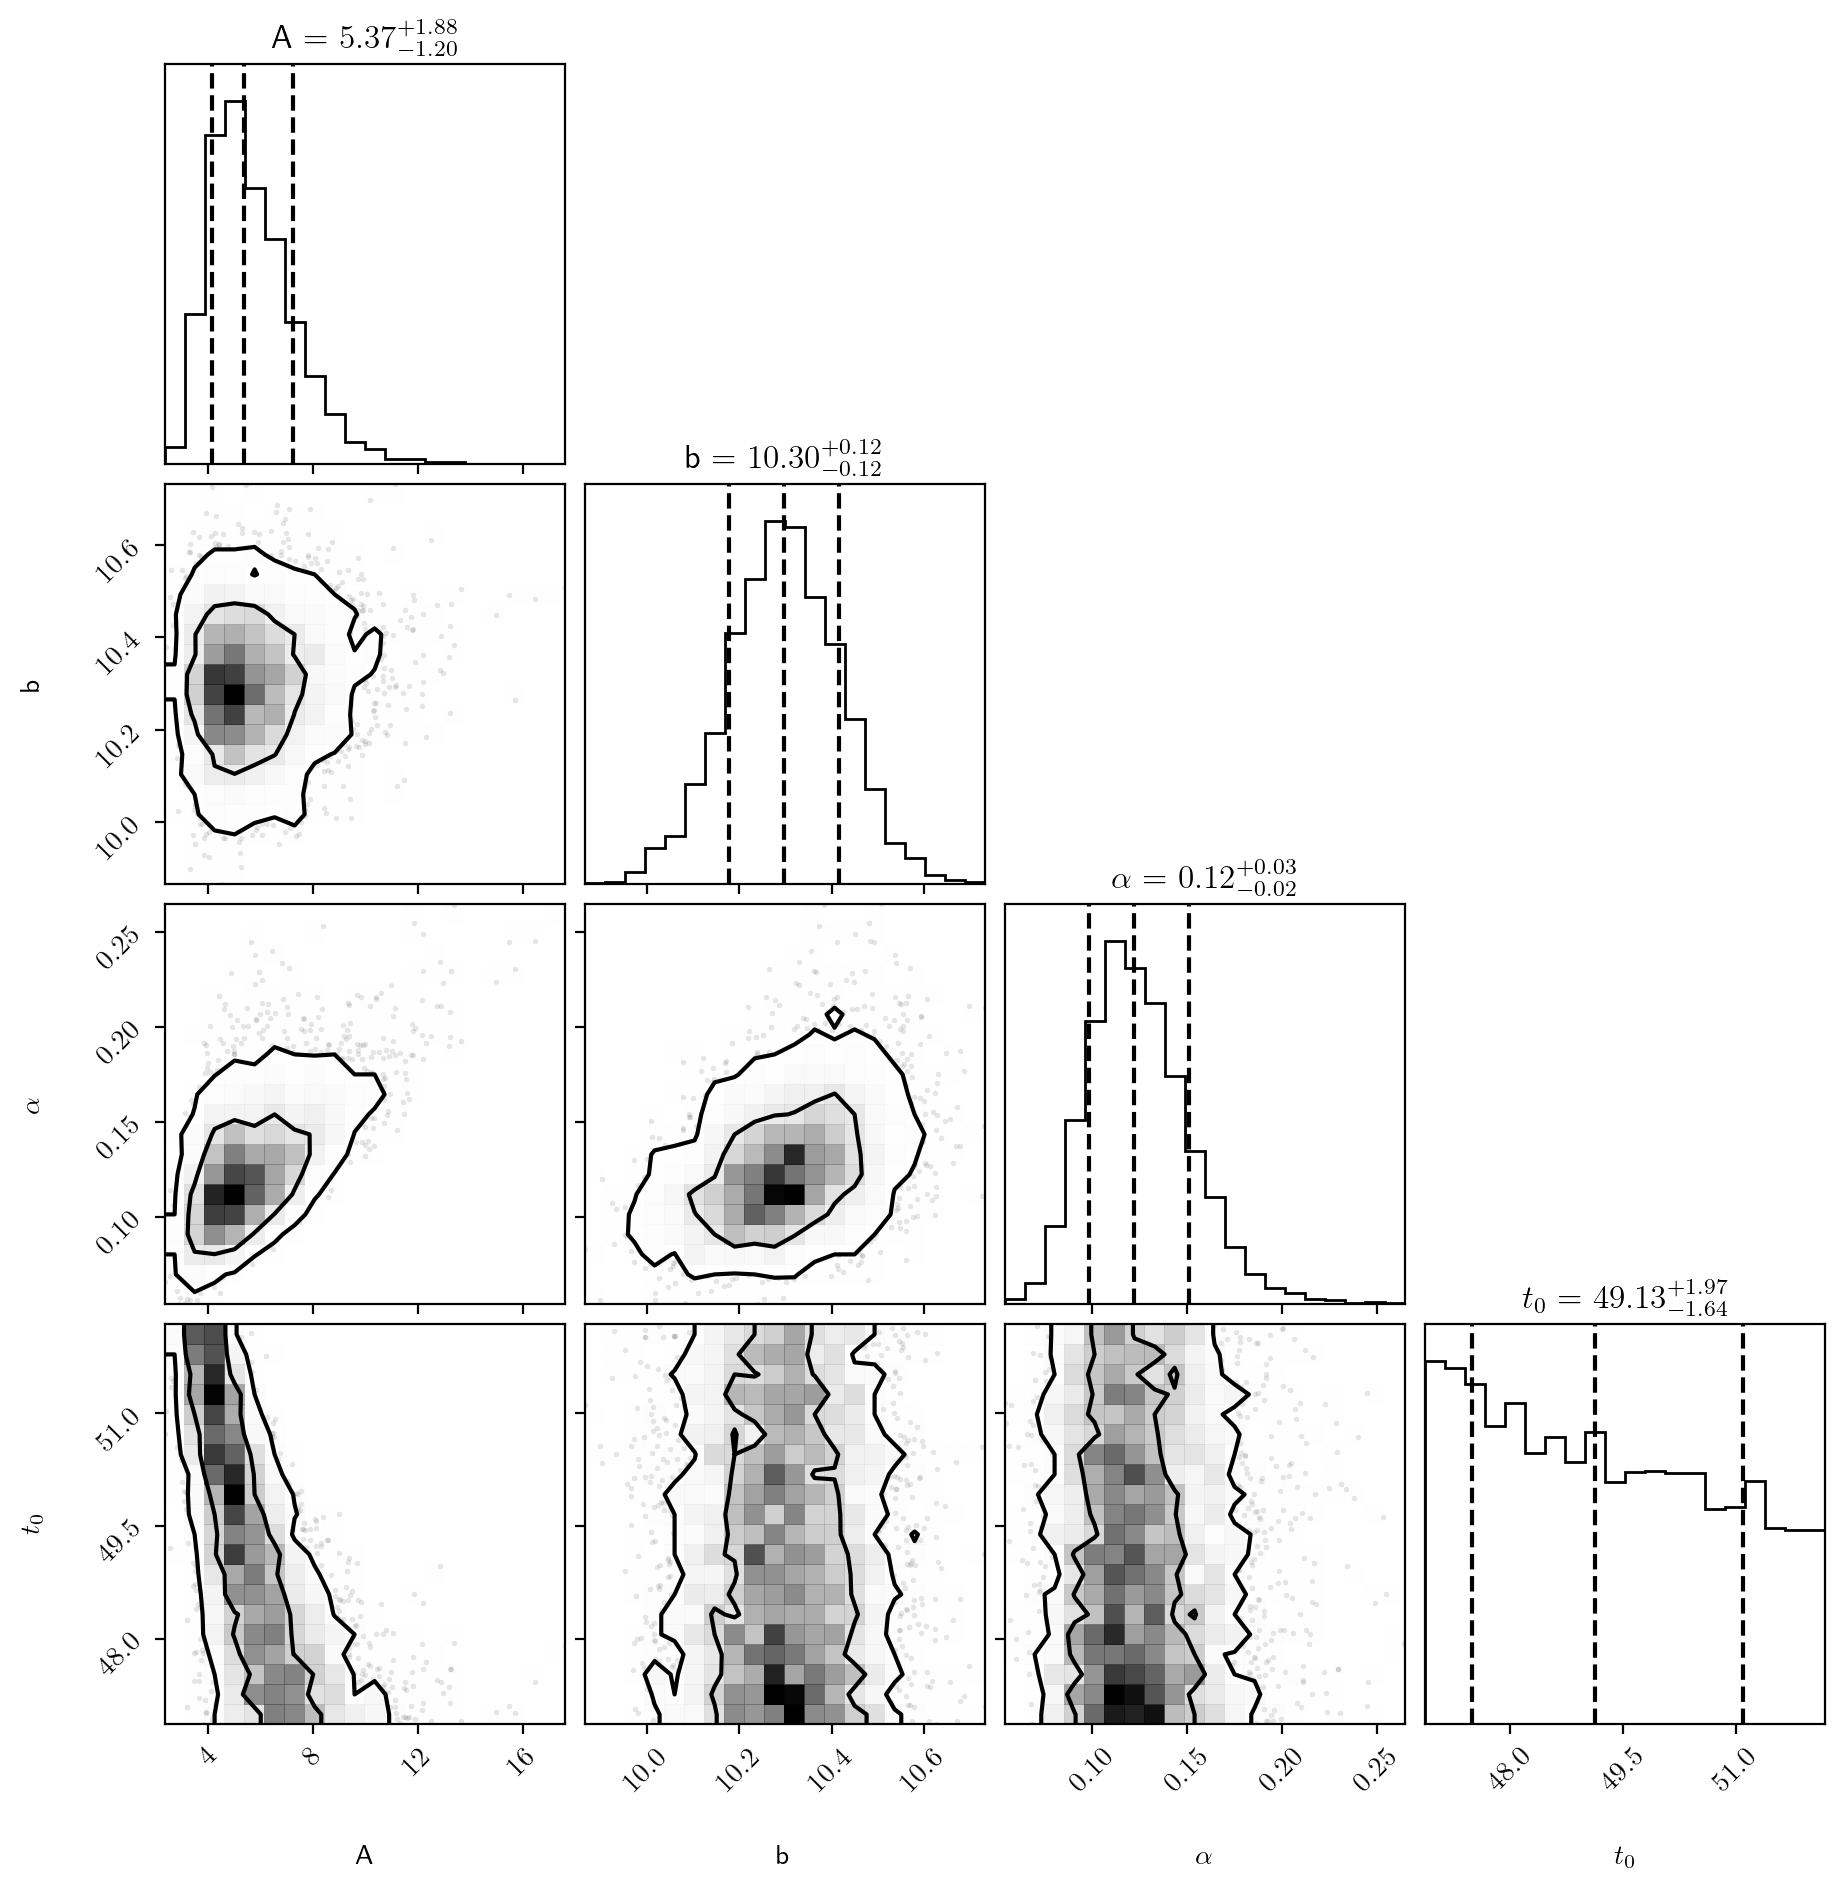

In [47]:
fig = corner.corner(
    flat_samples, labels=labels, levels=(0.68,0.95), quantiles=(0.16, 0.5, 0.84), show_titles=True
)

6) Now choose $100$ samples randomly from your burned, thinned chain and plot the $100$ corresponding burst time-series on a figure along with the original data. You may want to choose a transparency for these $100$ burst curves that allows you to see everything nicely. These are showing the posterior spread of model solutions that are consistent with the data.


In [31]:
samples = flat_samples[np.random.choice(len(flat_samples), 100, replace=False)]

Text(0, 0.5, 'flux')

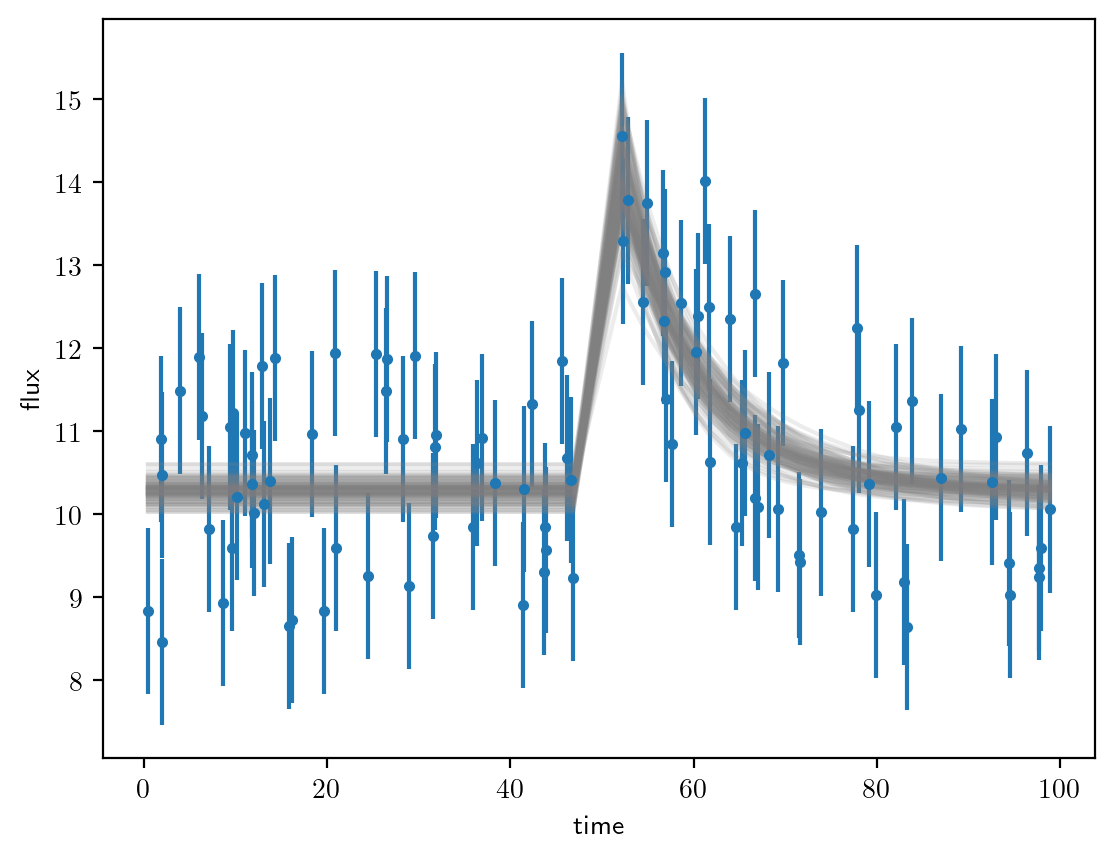

In [32]:
plt.errorbar(t, f, ferr, fmt='.')

for A, b, alpha, t0 in samples:
    plt.plot(t, model(t, A, b, alpha, t0), c='gray', alpha=0.15)

plt.xlabel('time')
plt.ylabel('flux')


7) For each parameter, find the median and 90% credible region of the marginalized distribution and quote results as, for instance, $t_0=X^{+Y}_{-Z}$ 



In [33]:
median = np.median(flat_samples, axis=0)
print('Medians = ', median)

Medians =  [ 5.36949203 10.29617883  0.12182104 49.13072353]


In [34]:
quantiles = np.percentile(flat_samples, q=[5, 50, 95], axis = 0) # equal-tailed interval

medians = quantiles[1]
low_tail = medians-quantiles[0]
high_tail = quantiles[2] - medians

print('Medians = ', medians)
print('90% credible region: median')
print('-',low_tail)
print('+',high_tail)


Medians =  [ 5.36949203 10.29617883  0.12182104 49.13072353]
90% credible region: median
- [1.77161879 0.20318993 0.03613116 2.07737564]
+ [3.3213728  0.19775743 0.05135307 2.70060128]
